In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from tensorflow.keras.utils import to_categorical

# Load the raw files you created in Part 1
print("Loading raw acoustic data...")
X_raw = np.load('X_raw_subset.npy')
y_labels = np.load('y_labels_subset.npy')
print(f"Loaded {len(X_raw)} samples.")

C:\Users\saide\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loading raw acoustic data...
Loaded 6813 samples.


In [2]:
X_images = []
print("Converting to 128x128 Mel-spectrograms...")

for i, signal in enumerate(X_raw):
    # Convert to Mel-scale and then to Decibels (Log Scale)
    mel = librosa.feature.melspectrogram(y=signal, sr=16000, n_mels=128)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    
    # Crop/Resize to exactly 128x128
    X_images.append(log_mel[:, :128])

# Convert to initial numpy array
X_train = np.array(X_images)
print(f"Created image array with shape: {X_train.shape}")

Converting to 128x128 Mel-spectrograms...
Created image array with shape: (6813, 128, 126)


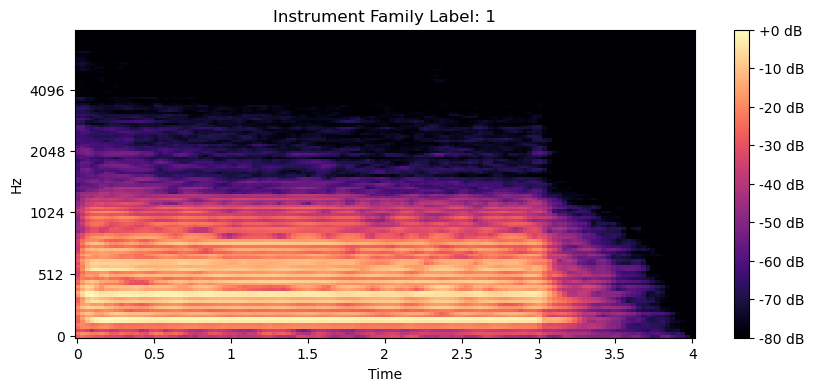

In [3]:
sample_idx = 0 
plt.figure(figsize=(10, 4))
librosa.display.specshow(X_train[sample_idx], sr=16000, x_axis='time', y_axis='mel')
plt.title(f"Instrument Family Label: {y_labels[sample_idx]}")
plt.colorbar(format='%+2.0f dB')
plt.show()

In [4]:
print("Normalizing and fixing array shapes...")

# 1. Normalize pixels between 0 and 1
X_train_norm = (X_train - X_train.min()) / (X_train.max() - X_train.min())

# 2. Use integer division to find how many 128x128 images fit perfectly
image_size = 128 * 128 * 1
num_samples = X_train_norm.size // image_size 

# 3. Trim the extra pixels and reshape to (Samples, 128, 128, 1)
X_train_final = X_train_norm.flatten()[:num_samples * image_size].reshape(num_samples, 128, 128, 1)

# 4. Synchronize and One-Hot Encode labels
y_labels_trimmed = y_labels[:num_samples]
y_train_encoded = to_categorical(y_labels_trimmed, num_classes=11)

print(f"Final Input Shape for CNN: {X_train_final.shape}") # Should be (6706, 128, 128, 1)
print(f"Final Label Shape: {y_train_encoded.shape}")

Normalizing and fixing array shapes...
Final Input Shape for CNN: (6706, 128, 128, 1)
Final Label Shape: (6706, 11)


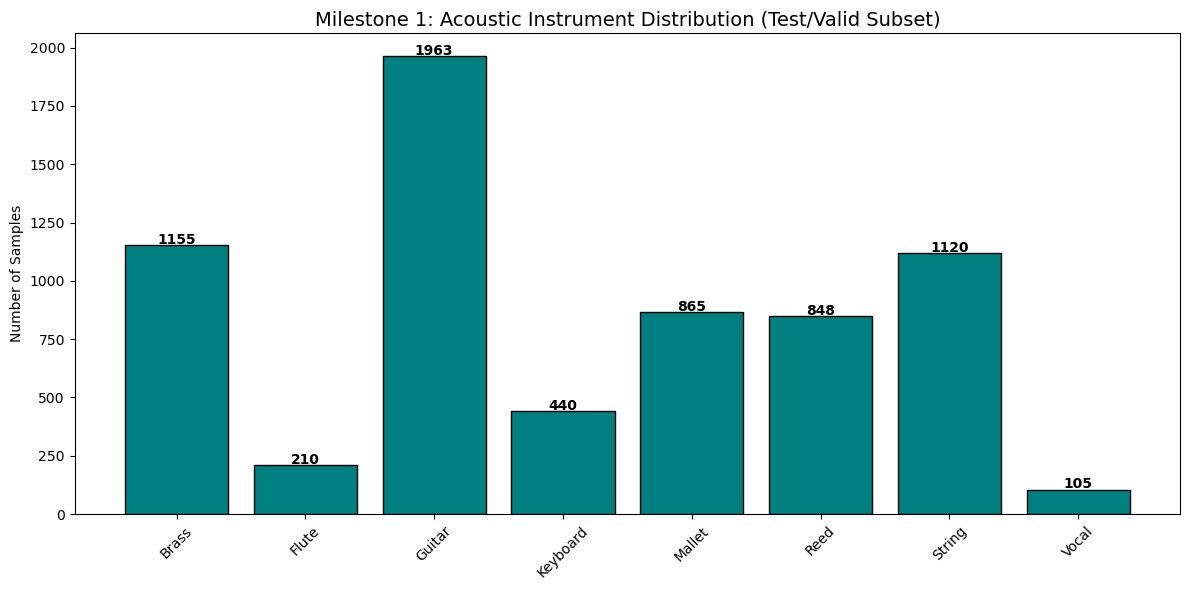

In [6]:
family_names = ['Bass', 'Brass', 'Flute', 'Guitar', 'Keyboard', 
                'Mallet', 'Organ', 'Reed', 'String', 'Synth', 'Vocal']

unique, counts = np.unique(y_labels_trimmed, return_counts=True)

plt.figure(figsize=(12, 6))
bars = plt.bar([family_names[i] for i in unique], counts, color='teal', edgecolor='black')
plt.title('Milestone 1: Acoustic Instrument Distribution (Test/Valid Subset)', fontsize=14)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import json
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model


In [8]:
print("Loading dataset...")

X = np.load('X.npy')
y = np.load('y.npy')

with open('label_map.json', 'r') as f:
    label_map = json.load(f)

num_classes = len(label_map)

print("Dataset shape:", X.shape)


Loading dataset...
Dataset shape: (5600, 128, 128)


In [9]:
X = X.astype('float32') / 255.0

if len(X.shape) == 3:
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

# Keep your one-hot encoding
y_encoded = to_categorical(y, num_classes=num_classes)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)


Train Shape: (4480, 128, 128, 1)
Validation Shape: (1120, 128, 128, 1)


In [10]:
def build_instrunet_cnn(input_shape, num_classes):

    model = models.Sequential([

        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        
        layers.Dense(num_classes, activation='sigmoid')
    ])

    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_instrunet_cnn(X_train.shape[1:], num_classes)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,096 (12.61 MB)

 Trainable params: 3,305,096 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [12]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)


Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 237ms/step - accuracy: 0.2268 - loss: 0.3815 - val_accuracy: 0.4062 - val_loss: 0.3027
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 222ms/step - accuracy: 0.4297 - loss: 0.3032 - val_accuracy: 0.5196 - val_loss: 0.2624
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.5002 - loss: 0.2683 - val_accuracy: 0.5839 - val_loss: 0.2358
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 221ms/step - accuracy: 0.5531 - loss: 0.2490 - val_accuracy: 0.6429 - val_loss: 0.2127
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.6107 - loss: 0.2275 - val_accuracy: 0.6946 - val_loss: 0.1920
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 207ms/step - accuracy: 0.6522 - loss: 0.2077 - val_accuracy: 0.7125 - val_loss: 0.1801
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.6663 - loss: 0.1963 - val_accuracy: 0.7232 - val_loss: 0.1725
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.6964 - loss: 0

In [19]:
model.save("instrunet_final.keras")
print("Model saved successfully!")

Model saved successfully!


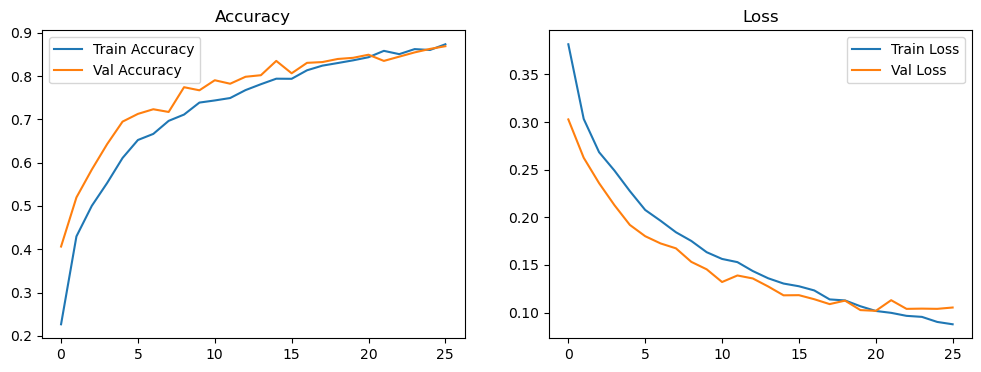

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step

 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       159
           1       0.82      0.89      0.85       141
           2       0.84      0.78      0.81       138
           3       0.88      0.81      0.84       150
           4       0.72      0.76      0.74       121
           5       0.86      0.67      0.75       136
           6       0.82      0.95      0.88       135
           7       0.98      0.99      0.98       140

    accuracy                           0.85      1120
   macro avg       0.85      0.85      0.84      1120
weighted avg       0.85      0.85      0.85      1120



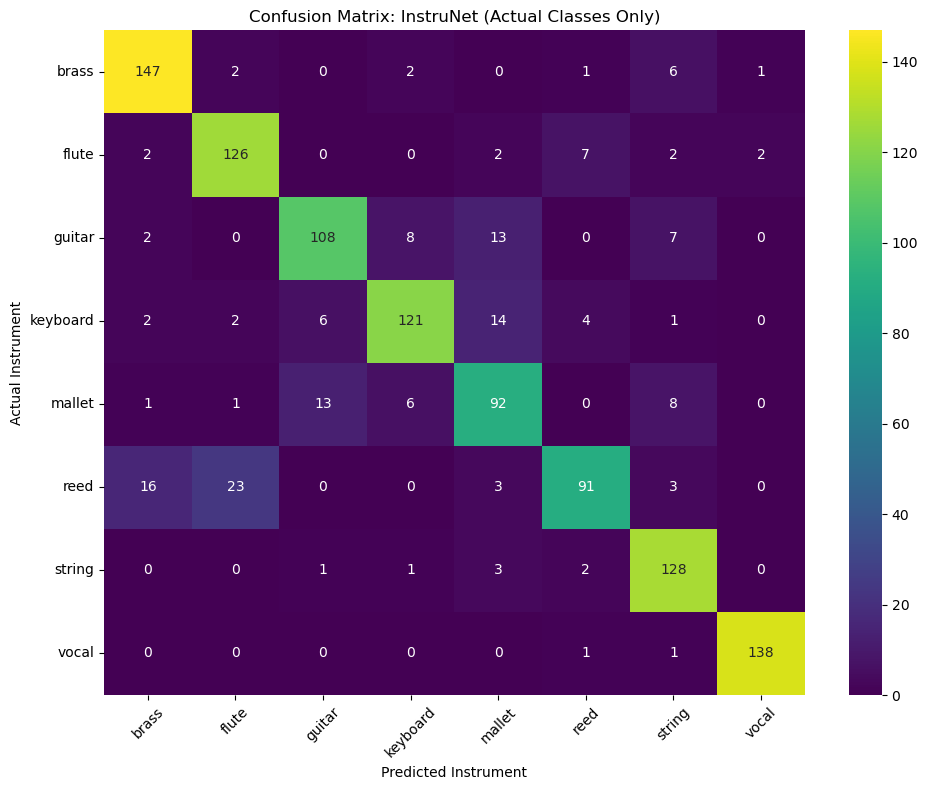

In [24]:
y_pred_probs = model.predict(X_val)

# Dataset is single-label → use argmax for evaluation
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

print("\n==============================")
print(" CLASSIFICATION REPORT")
print("==============================\n")

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

inv_label_map = {v: k for k, v in label_map.items()}
class_names = [inv_label_map[i] for i in range(len(inv_label_map))]

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=class_names,
    yticklabels=class_names
)

# Title and Axis Labels
plt.title("Confusion Matrix: InstruNet (Actual Classes Only)")
plt.xlabel("Predicted Instrument")
plt.ylabel("Actual Instrument")

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
def preprocess_audio(audio_path, sr=16000):

    signal, _ = librosa.load(audio_path, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=128
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    if log_mel.shape[1] < 128:
        pad_width = 128 - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0,0),(0,pad_width)))
    else:
        log_mel = log_mel[:, :128]

    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min())

    log_mel = log_mel.reshape(1,128,128,1)

    return log_mel


In [45]:
model = load_model("instrunet_final.keras")

inv_label_map = {v: k for k, v in label_map.items()}

audio_path = "sample_82522.wav" 

X_input = preprocess_audio(audio_path)

prediction = model.predict(X_input)[0]

threshold = 0.5
results = {}

for i, prob in enumerate(prediction):
    if prob > threshold:
        instrument = inv_label_map[i]
        confidence = float(round(prob * 100, 2))  
        results[instrument] = confidence
        print(f"{instrument} : {confidence}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
brass : 100.0%


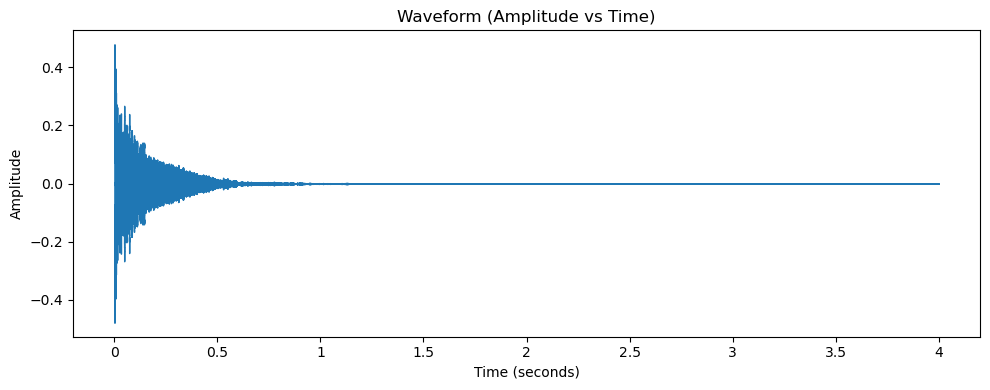

In [46]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

audio_path = "sample_82522.wav"

signal, sr = librosa.load(audio_path, sr=16000)

plt.figure(figsize=(10,4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Waveform (Amplitude vs Time)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


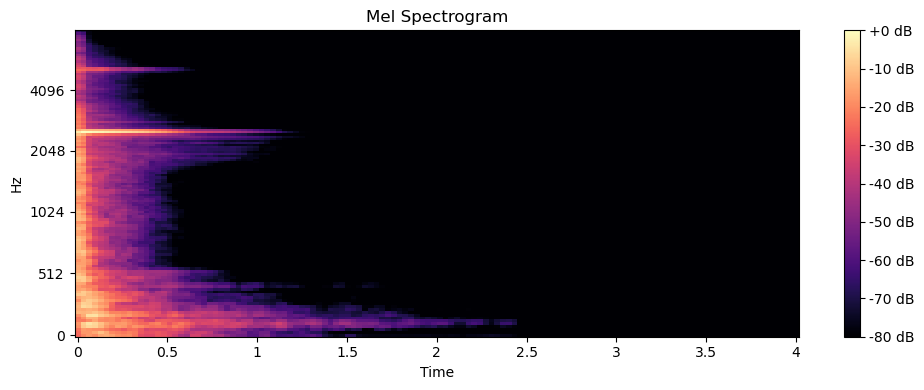

In [47]:
mel = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128
)

log_mel = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    log_mel,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()


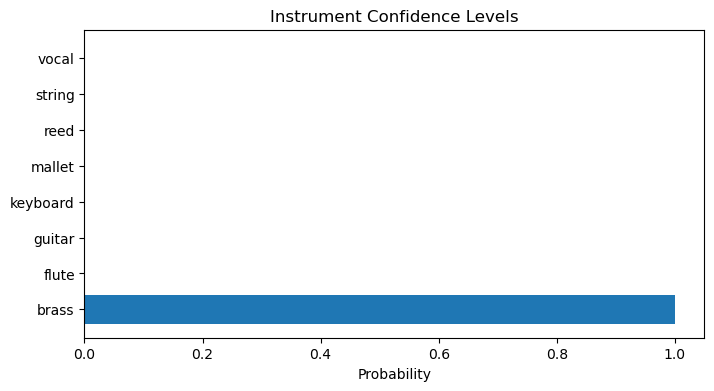

In [48]:
plt.figure(figsize=(8,4))
plt.barh(class_names, prediction)
plt.xlabel("Probability")
plt.title("Instrument Confidence Levels")
plt.show()

In [49]:
def segment_wise_prediction(audio_path, segment_duration=1.0, sr=16000):

    signal, _ = librosa.load(audio_path, sr=sr, mono=True)

    segment_length = int(segment_duration * sr)
    total_segments = len(signal) // segment_length

    timeline_results = []

    for i in range(total_segments):

        start = i * segment_length
        end = start + segment_length
        segment = signal[start:end]

        # Generate Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128
        )

        log_mel = librosa.power_to_db(mel, ref=np.max)

        if log_mel.shape[1] < 128:
            pad_width = 128 - log_mel.shape[1]
            log_mel = np.pad(log_mel, ((0,0),(0,pad_width)))
        else:
            log_mel = log_mel[:, :128]

        
        denominator = log_mel.max() - log_mel.min()

        if denominator != 0:
            log_mel = (log_mel - log_mel.min()) / denominator
        else:
            log_mel = np.zeros_like(log_mel)

        log_mel = log_mel.reshape(1,128,128,1)

        prediction = model.predict(log_mel)[0]

        timeline_results.append(prediction)

    return np.array(timeline_results)


In [51]:
audio_path = "sample_82522.wav"

timeline_preds = segment_wise_prediction(audio_path)

print("Timeline shape:", timeline_preds.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Timeline shape: (4, 8)


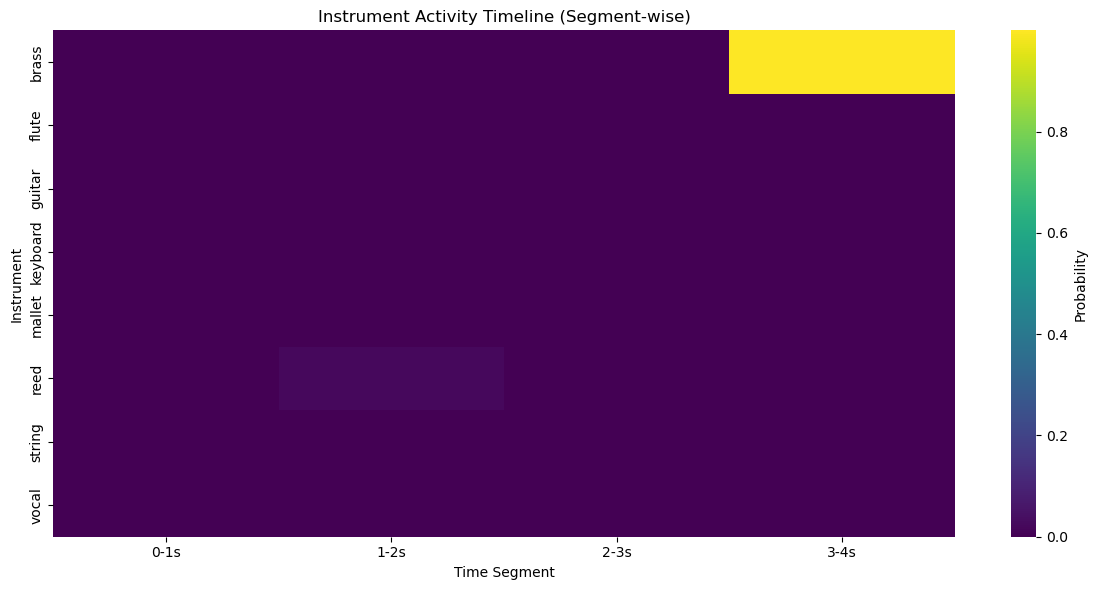

In [52]:
plt.figure(figsize=(12,6))

sns.heatmap(
    timeline_preds.T,   # Transpose so instruments are rows
    cmap="viridis",
    xticklabels=[f"{i}-{i+1}s" for i in range(timeline_preds.shape[0])],
    yticklabels=class_names,
    cbar_kws={'label': 'Probability'}
)

plt.title("Instrument Activity Timeline (Segment-wise)")
plt.xlabel("Time Segment")
plt.ylabel("Instrument")
plt.tight_layout()
plt.show()


In [56]:
import json
from datetime import datetime

# Get dominant prediction
dominant_idx = np.argmax(prediction)
dominant_conf = float(round(prediction[dominant_idx] * 100, 2))
dominant_instrument = class_names[dominant_idx]

# Build timeline summary
timeline_summary = []

for i, segment in enumerate(timeline_preds):
    seg_idx = np.argmax(segment)
    seg_conf = float(round(segment[seg_idx] * 100, 2))

    timeline_summary.append({
        "segment": f"{i}-{i+1} sec",
        "instrument": class_names[seg_idx],
        "confidence_percent": seg_conf
    })

# Create full report dictionary
report_data = {
    "project_name": "InstruNet AI - CNN Based Instrument Recognition",
    "audio_file": audio_path,
    "analysis_time": str(datetime.now()),
    "overall_prediction": {
        "instrument": dominant_instrument,
        "confidence_percent": dominant_conf
    },
    "timeline_analysis": timeline_summary,
    "model_performance": {
        "validation_accuracy": "86.8%",
        "loss_function": "Binary Crossentropy",
        "activation": "Sigmoid"
    }
}

# Save JSON
with open("instrument_analysis_report.json", "w") as f:
    json.dump(report_data, f, indent=4)

print("JSON report saved successfully.")


JSON report saved successfully.


In [57]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.platypus import TableStyle
from reportlab.lib.units import inch

def generate_pdf_report(report_data, filename="instrument_analysis_report.pdf"):

    doc = SimpleDocTemplate(filename)
    elements = []
    styles = getSampleStyleSheet()

    elements.append(Paragraph("<b>InstruNet AI - Instrument Analysis Report</b>", styles["Title"]))
    elements.append(Spacer(1, 0.4 * inch))

    elements.append(Paragraph(f"Audio File: {report_data['audio_file']}", styles["Normal"]))
    elements.append(Paragraph(f"Analysis Time: {report_data['analysis_time']}", styles["Normal"]))
    elements.append(Spacer(1, 0.3 * inch))

    elements.append(Paragraph("<b>Overall Prediction</b>", styles["Heading2"]))
    elements.append(Paragraph(
        f"Instrument: {report_data['overall_prediction']['instrument']} "
        f"({report_data['overall_prediction']['confidence_percent']}%)",
        styles["Normal"]
    ))
    elements.append(Spacer(1, 0.3 * inch))

    elements.append(Paragraph("<b>Timeline Analysis</b>", styles["Heading2"]))

    table_data = [["Segment", "Instrument", "Confidence (%)"]]

    for row in report_data["timeline_analysis"]:
        table_data.append([
            row["segment"],
            row["instrument"],
            str(row["confidence_percent"])
        ])

    table = Table(table_data)
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 1, colors.black)
    ]))

    elements.append(table)

    doc.build(elements)

    print("PDF report generated successfully.")

# Generate PDF
generate_pdf_report(report_data)


PDF report generated successfully.
